# 02 Traditional Augmentation Experiment

This notebook trains the same EfficientNet-B0 baseline model, but balances the training set by adding duplicated melanoma rows.  
Only the duplicated melanoma rows receive traditional image augmentation. Validation and test sets remain unchanged.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Mounted at /content/drive
cpu


In [2]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df = pd.read_csv(SPLIT_DIR / "train_split.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df.head())
print("\nOriginal training distribution:")
print(train_df["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  

Original training distribution:
label
0    7261
1     943
Name: count, dtype: int64


## Copy images locally in Colab

This is optional but useful because reading images directly from Google Drive is slower.

In [6]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

        326.28M 100%   36.51kB/s    2:25:25 (xfr#11721, to-chk=0/11722)   


In [7]:
old_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_path = "/content/HAM10000_images"

train_df["image_path"] = train_df["image_path"].str.replace(old_path, new_path, regex=False)
val_df["image_path"] = val_df["image_path"].str.replace(old_path, new_path, regex=False)
test_df["image_path"] = test_df["image_path"].str.replace(old_path, new_path, regex=False)

print(train_df["image_path"].iloc[0])
print("First train image exists:", Path(train_df["image_path"].iloc[0]).exists())

train_exists = train_df["image_path"].apply(lambda p: Path(p).exists())
val_exists = val_df["image_path"].apply(lambda p: Path(p).exists())
test_exists = test_df["image_path"].apply(lambda p: Path(p).exists())

print("Missing train images:", (~train_exists).sum())
print("Missing validation images:", (~val_exists).sum())
print("Missing test images:", (~test_exists).sum())

/content/HAM10000_images/ISIC_0024307.jpg
First train image exists: True
Missing train images: 0
Missing validation images: 0
Missing test images: 0


## Create balanced training dataframe

This does **not** create new image files.  
It duplicates melanoma rows in the dataframe. The duplicated rows will receive random traditional transformations when loaded by the Dataset class.

In [8]:
# Separate classes
mel_df = train_df[train_df["label"] == 1].copy()
non_mel_df = train_df[train_df["label"] == 0].copy()

# Calculate how many melanoma samples are needed to balance the training set
num_to_generate = len(non_mel_df) - len(mel_df)

print("Original training distribution:")
print(train_df["label"].value_counts())

print("\nNeed to create:", num_to_generate, "augmented melanoma samples")

# Sample melanoma rows with replacement
aug_mel_df = mel_df.sample(
    n=num_to_generate,
    replace=True,
    random_state=42
).copy()

# Mark original and augmented rows
train_df["is_augmented"] = False
aug_mel_df["is_augmented"] = True

# Combine original training set + duplicated melanoma rows
train_aug_df = pd.concat([train_df, aug_mel_df], ignore_index=True)

print("\nNew training distribution:")
print(train_aug_df["label"].value_counts())

print("\nAugmentation flag distribution:")
print(train_aug_df["is_augmented"].value_counts())

Original training distribution:
label
0    7261
1     943
Name: count, dtype: int64

Need to create: 6318 augmented melanoma samples

New training distribution:
label
0    7261
1    7261
Name: count, dtype: int64

Augmentation flag distribution:
is_augmented
False    8204
True     6318
Name: count, dtype: int64


## Define transforms

Original rows receive only resize + normalization.  
Duplicated melanoma rows receive random crop, flips, rotation, and mild colour jitter.

In [9]:
base_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

traditional_aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, base_transform=None, aug_transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_transform = base_transform
        self.aug_transform = aug_transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        # True only for duplicated melanoma rows in train_aug_df
        is_augmented = row.get("is_augmented", False)

        if is_augmented and self.aug_transform is not None:
            image = self.aug_transform(image)
        elif self.base_transform is not None:
            image = self.base_transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [11]:
BATCH_SIZE = 32

train_dataset = MelanomaDataset(
    dataframe=train_aug_df,
    base_transform=base_train_transform,
    aug_transform=traditional_aug_transform
)

val_dataset = MelanomaDataset(
    dataframe=val_df,
    base_transform=eval_transform,
    aug_transform=None
)

test_dataset = MelanomaDataset(
    dataframe=test_df,
    base_transform=eval_transform,
    aug_transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 14522
Validation dataset size: 1742
Test dataset size: 1774


In [12]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 236MB/s]


In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs


def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds)
    }

In [22]:
# Recreate model from scratch for this experiment
weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

# Recreate loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [23]:
EPOCHS = 50

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")


Epoch 1/50


100%|██████████| 55/55 [00:04<00:00, 12.24it/s]


Train loss: 0.1860
Val loss: 0.2357
Accuracy: 0.8984
Precision: 0.5588
Recall: 0.3938
F1-score: 0.4620
ROC-AUC: 0.8963
New best model saved.

Epoch 2/50


100%|██████████| 55/55 [00:04<00:00, 12.57it/s]


Train loss: 0.1051
Val loss: 0.2242
Accuracy: 0.8984
Precision: 0.5426
Recall: 0.5285
F1-score: 0.5354
ROC-AUC: 0.9140
New best model saved.

Epoch 3/50


...

Train loss: 0.0053
Val loss: 0.4754
Accuracy: 0.9076
Precision: 0.6026
Recall: 0.4870
F1-score: 0.5387
ROC-AUC: 0.9130

Epoch 49/50


100%|██████████| 55/55 [00:04<00:00, 12.23it/s]


Train loss: 0.0043
Val loss: 0.4953
Accuracy: 0.9082
Precision: 0.6170
Recall: 0.4508
F1-score: 0.5210
ROC-AUC: 0.9037

Epoch 50/50


100%|██████████| 55/55 [00:04<00:00, 12.36it/s]

Train loss: 0.0035
Val loss: 0.5682
Accuracy: 0.8955
Precision: 0.5301
Recall: 0.5026
F1-score: 0.5160
ROC-AUC: 0.9080

Training finished.
Best epoch: 30
Best validation F1-score: 0.5808


In [24]:
CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "efficientnet_b0_traditional_aug_best_50_epoch.pth"
)

history_df.to_csv(
    RESULTS_DIR / "efficientnet_b0_traditional_aug_training_history_50_epoch.csv",
    index=False
)

print("Saved:")
print(CHECKPOINT_DIR / "efficientnet_b0_traditional_aug_best_50_epoch.pth")
print(RESULTS_DIR / "efficientnet_b0_traditional_aug_training_history_50_epoch.csv")

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/efficientnet_b0_traditional_aug_best_50_epoch.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/efficientnet_b0_traditional_aug_training_history_50_epoch.csv


In [20]:
# Final validation evaluation using the best model

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_val_metrics["confusion_matrix"])

100%|██████████| 55/55 [00:04<00:00, 12.43it/s]


Best model validation results:
Val loss: 0.2319
Accuracy: 0.9191
Precision: 0.6494
Recall: 0.5855
F1-score: 0.6158
ROC-AUC: 0.9246
Confusion matrix:
[[1488   61]
 [  80  113]]


In [21]:
# Final test evaluation using the best model

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_metrics = calculate_metrics(
    labels=test_labels,
    probs=test_probs,
    threshold=0.5
)

test_results = {
    "experiment": "traditional_augmentation",
    "test_loss": test_loss,
    "accuracy": test_metrics["accuracy"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "roc_auc": test_metrics["roc_auc"]
}

test_results_df = pd.DataFrame([test_results])

test_results_df.to_csv(
    RESULTS_DIR / "efficientnet_b0_traditional_aug_test_results.csv",
    index=False
)

print("\nBest model test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"ROC-AUC: {test_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(test_metrics["confusion_matrix"])

test_results_df

100%|██████████| 56/56 [00:04<00:00, 12.24it/s]


Best model test results:
Test loss: 0.2073
Accuracy: 0.9278
Precision: 0.6376
Recall: 0.5621
F1-score: 0.5975
ROC-AUC: 0.9238
Confusion matrix:
[[1551   54]
 [  74   95]]


,experiment,test_loss,accuracy,precision,recall,f1,roc_auc
0,traditional_augmentation,0.207347,0.927847,0.637584,0.56213,0.597484,0.923829


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.196411,0.223183,0.910448,0.624161,0.481865,0.543860,0.905241
1,2,0.109244,0.241230,0.901837,0.582090,0.404145,0.477064,0.890673
2,3,0.069228,0.231920,0.919059,0.649425,0.585492,0.615804,0.924605
3,4,0.047293,0.297204,0.901263,0.558011,0.523316,0.540107,0.905712
4,5,0.033854,0.291930,0.908152,0.589189,0.564767,0.576720,0.908535
5,6,0.024757,0.319366,0.918485,0.683453,0.492228,0.572289,0.897199
6,7,0.022159,0.325274,0.911596,0.611429,0.554404,0.581522,0.906067
7,8,0.017414,0.378473,0.909874,0.616883,0.492228,0.547550,0.901424
8,9,0.014616,0.382242,0.899541,0.548913,0.523316,0.535809,0.894115
9,10,0.015869,0.396508,0.909874,0.625000,0.466321,0.534125,0.897632


Lowest validation loss:
Epoch 1, val_loss = 0.2232

Highest validation F1-score:
Epoch 3, F1 = 0.6158


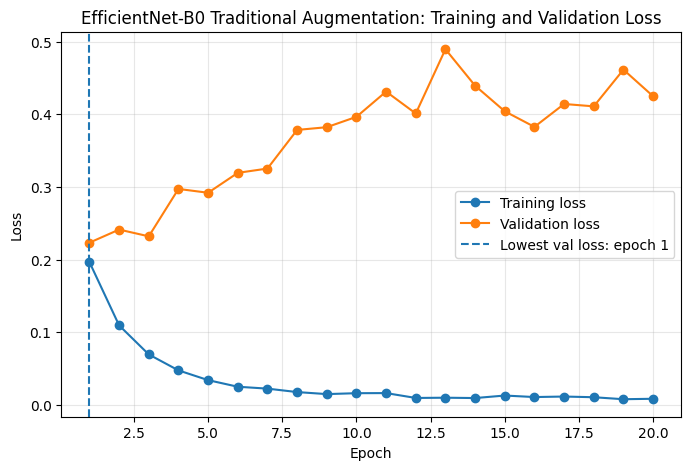

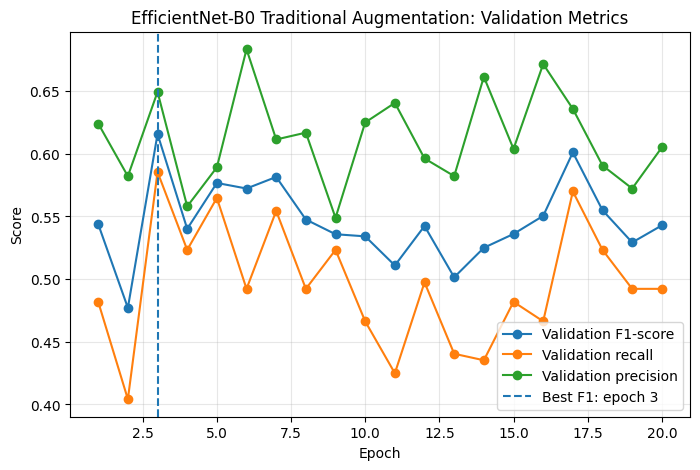

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load saved training history
HISTORY_PATH = "/content/drive/MyDrive/bachelor_thesis_data/results/tables/efficientnet_b0_traditional_aug_training_history.csv"

history_df = pd.read_csv(HISTORY_PATH)

display(history_df)

# Find best epoch according to validation loss
best_val_loss_idx = history_df["val_loss"].idxmin()
best_val_loss_epoch = int(history_df.loc[best_val_loss_idx, "epoch"])
best_val_loss = history_df.loc[best_val_loss_idx, "val_loss"]

# Find best epoch according to validation F1-score
best_f1_idx = history_df["f1"].idxmax()
best_f1_epoch = int(history_df.loc[best_f1_idx, "epoch"])
best_f1 = history_df.loc[best_f1_idx, "f1"]

print("Lowest validation loss:")
print(f"Epoch {best_val_loss_epoch}, val_loss = {best_val_loss:.4f}")

print("\nHighest validation F1-score:")
print(f"Epoch {best_f1_epoch}, F1 = {best_f1:.4f}")

# Create figure directory
FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Lowest val loss: epoch {best_val_loss_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Traditional Augmentation: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "efficientnet_b0_baseline_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Plot validation metrics
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["f1"], marker="o", label="Validation F1-score")
plt.plot(history_df["epoch"], history_df["recall"], marker="o", label="Validation recall")
plt.plot(history_df["epoch"], history_df["precision"], marker="o", label="Validation precision")

plt.axvline(
    best_f1_epoch,
    linestyle="--",
    label=f"Best F1: epoch {best_f1_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("EfficientNet-B0 Traditional Augmentation: Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "efficientnet_b0_traditional_aug_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

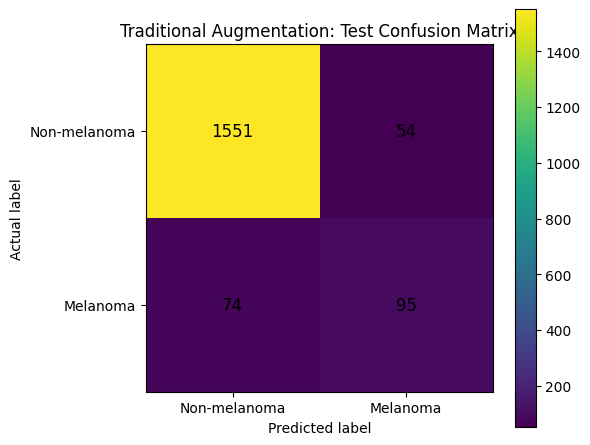

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Baseline test confusion matrix
# Rows = actual labels, columns = predicted labels
cm = np.array([
    [1551, 54],
    [74, 95]
])

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Traditional Augmentation: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURE_DIR / "efficientnet_b0_traditional_augmentation_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()